# Postings analysis

Loads the canonical clean table from `data/processed/postings.parquet` (frozen
schema in `docs/schema.md`). One row = one unique posting after dedup.

**Caveats baked into every section below:**
- `role_category` is a coarse pre-cluster label, not the final taxonomy.
- Salary figures cover only rows with `salary_present=True` (~32%); always read
  coverage alongside pay stats. Distribution stats use a plausibility band
  (§4); the median is the headline.
- `skills` is populated only where LLM extraction ran (data-family rows); `null`
  means extraction did not run. Skills/seniority are **LLM output, unvalidated
  against human ground truth** (verification eval dropped from scope) — treat
  skills/seniority-based claims as provisional.
- Skill tokens are alias-normalized in §5 (e.g. `google cloud platform` → `gcp`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Repo root: notebooks/ is one level below the project root
REPO_ROOT = Path("..").resolve()
PARQUET_PATH = REPO_ROOT / "data" / "processed" / "postings.parquet"

if not PARQUET_PATH.exists():
    raise FileNotFoundError(
        f"Missing {PARQUET_PATH}. Run: python src/extract.py"
    )

df = pd.read_parquet(PARQUET_PATH)
n = len(df)
print(f"Loaded {n:,} postings from {PARQUET_PATH.name}")

Loaded 10,846 postings from postings.parquet


In [2]:
# Skill alias map — the LLM didn't fully canonicalise, so the same tool appears
# under several tokens (google cloud platform / gcp, microsoft azure / azure, …).
# Merge them so skill counts don't split. pyspark is kept distinct from spark
# (it's the Python API, a meaningfully different skill signal).
SKILL_ALIASES = {
    "google cloud platform": "gcp",
    "microsoft azure": "azure",
    "amazon web services": "aws",
    "apache spark": "spark",
    "apache kafka": "kafka",
    "apache airflow": "airflow",
    "ml": "machine learning",
    "powerbi": "power bi",
    "power-bi": "power bi",
    "scikit learn": "scikit-learn",
    "sklearn": "scikit-learn",
    "gen ai": "genai",
    "generative ai": "genai",
    "ci cd": "ci/cd",
    "postgresql": "postgres",
}


def normalize_skills(skills):
    """Lowercase, alias-map, and de-dup a posting's skill list -> python list.

    Accepts list / numpy array (Parquet returns list columns as ndarrays);
    returns None for nulls / scalars / strings (i.e. "extraction did not run").
    """
    if isinstance(skills, str) or not hasattr(skills, "__len__"):
        return None  # None, pd.NA, NaN, scalars
    out, seen = [], set()
    for s in skills:
        t = SKILL_ALIASES.get(str(s).strip().lower(), str(s).strip().lower())
        if t and t not in seen:
            seen.add(t)
            out.append(t)
    return out


df["skills_norm"] = df["skills"].apply(normalize_skills)
print("skills normalized; rows with skills:", df["skills_norm"].apply(lambda l: isinstance(l, list)).sum())

skills normalized; rows with skills: 4919


## 1. Table overview

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10846 entries, 0 to 10845
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype              
---  ------                     --------------  -----              
 0   posting_id                 10846 non-null  string             
 1   source                     10846 non-null  category           
 2   source_id                  10846 non-null  string             
 3   url                        10846 non-null  string             
 4   raw_file                   10846 non-null  string             
 5   pulled_at                  10846 non-null  datetime64[ns, UTC]
 6   posted_at                  10846 non-null  object             
 7   dup_count                  10846 non-null  Int64              
 8   title                      10846 non-null  string             
 9   role_category              10846 non-null  category           
 10  seniority                  10846 non-null  category           
 11  company      

In [4]:
# Key coverage flags (schema: always report salary_present alongside pay)
coverage = pd.Series(
    {
        "salary_present": df["salary_present"].mean(),
        "extracted (LLM)": df["extracted"].mean(),
        "skills populated": df["skills"].notna().mean(),
        "company present": df["company"].notna().mean(),
        "city present": df["city"].notna().mean(),
    }
).mul(100).round(1)
coverage.rename("pct").to_frame()

,pct
salary_present,32.4
extracted (LLM),45.4
skills populated,45.4
company present,98.8
city present,84.4


In [5]:
df.head(3)[[
    "posting_id", "title", "role_category", "seniority",
    "company", "city", "salary_present", "salary_midpoint_pln_month",
    "skills",
]]

,posting_id,title,role_category,seniority,company,city,salary_present,salary_midpoint_pln_month,skills
0,adzuna:5727482372,Analityk / Analityczka danych systemów informa...,data_analyst,mid,Sante,Warszawa,True,15285.5,"[ms sql server, t-sql]"
1,adzuna:5722317118,Analityk / Analityczka Danych @ DCG sp. z o.o.,data_analyst,senior,DCG sp. z o.o.,Warszawa,False,<NA>,"[python, sql, rad, llm]"
2,adzuna:5738938314,Analityk / Analityczka Danych,data_analyst,junior,Netvest Sp. z o.o.,Gdańsk,False,<NA>,"[excel, power query, bitrix24]"


## 2. Demand — role families

In [6]:
DATA_FAMILIES = [
    "data_analyst", "data_engineer", "data_scientist", "ml_engineer",
    "analytics_engineer", "bi_developer", "data_architect", "other",
]

role_counts = (
    df["role_category"]
    .value_counts()
    .rename_axis("role_category")
    .to_frame("count")
    .assign(pct=lambda x: (100 * x["count"] / n).round(1))
)
role_counts

,count,pct
role_category,,
unknown,5927,54.6
data_engineer,1647,15.2
data_analyst,1109,10.2
other,754,7.0
ml_engineer,556,5.1
data_scientist,349,3.2
bi_developer,234,2.2
data_architect,164,1.5
analytics_engineer,106,1.0


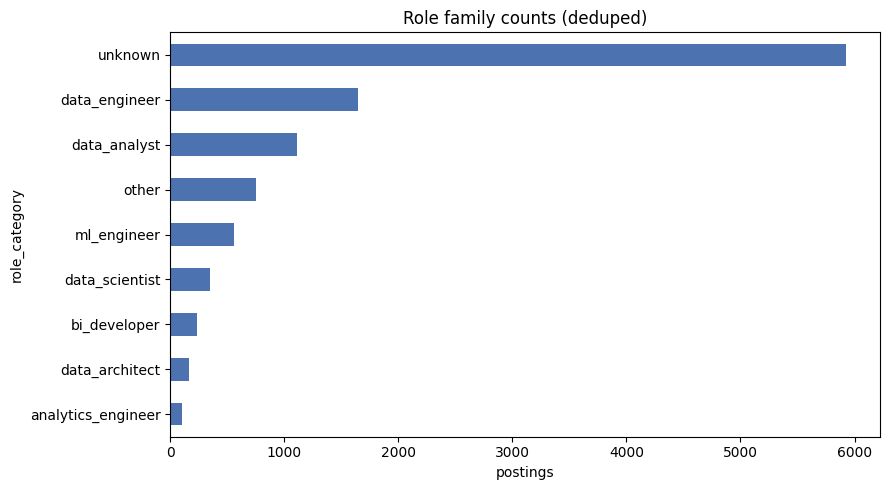

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))
role_counts["count"].sort_values().plot.barh(ax=ax, color="#4C72B0")
ax.set_xlabel("postings")
ax.set_title("Role family counts (deduped)")
plt.tight_layout()
plt.show()

In [8]:
# Data-family slice only (excludes the broad 'unknown' keyword noise)
data_df = df[df["role_category"].isin(DATA_FAMILIES)]
print(f"Data-family rows: {len(data_df):,} / {n:,} ({100 * len(data_df) / n:.1f}%)")

data_df["role_category"].value_counts().to_frame("count")

Data-family rows: 4,919 / 10,846 (45.4%)


,count
role_category,
data_engineer,1647
data_analyst,1109
other,754
ml_engineer,556
data_scientist,349
bi_developer,234
data_architect,164
analytics_engineer,106
unknown,0


## 3. Seniority

In [9]:
seniority = (
    data_df["seniority"]
    .value_counts()
    .reindex(["junior", "mid", "senior", "lead", "unknown"], fill_value=0)
    .rename_axis("seniority")
    .to_frame("count")
)
seniority.assign(pct=lambda x: (100 * x["count"] / len(data_df)).round(1))

,count,pct
seniority,,
junior,202,4.1
mid,1410,28.7
senior,1739,35.4
lead,382,7.8
unknown,1186,24.1


In [10]:
pd.crosstab(
    data_df["role_category"],
    data_df["seniority"],
    margins=True,
    normalize="index",
).mul(100).round(1)

seniority,junior,lead,mid,senior,unknown
role_category,,,,,
analytics_engineer,0.0,0.0,51.9,22.6,25.5
bi_developer,4.7,6.0,47.0,17.5,24.8
data_analyst,11.7,2.3,25.2,28.4,32.5
data_architect,0.0,17.7,0.0,82.3,0.0
data_engineer,1.4,5.4,30.1,37.8,25.3
data_scientist,2.0,14.3,24.9,35.8,22.9
ml_engineer,0.7,10.3,29.1,36.9,23.0
other,3.6,15.6,29.3,35.9,15.5
All,4.1,7.8,28.7,35.4,24.1


## 4. Pay — monthly PLN (salary-present rows only)

Stored values are period+currency normalized only. Adzuna v1 gives no gross/net
or UoP/B2B basis (`salary_basis_*` = `unknown`). Outliers flagged in extract
have `salary_period_raw='unknown'` and were not divided by 12.

In [11]:
paid = df[df["salary_present"]].copy()
print(f"Salary disclosed: {len(paid):,} / {n:,} ({100 * len(paid) / n:.1f}%)")
print(f"salary_is_estimated all false: {paid['salary_is_estimated'].eq(False).all()}")

# Plausibility band for distribution stats: a few normalized monthly values still
# slip the extract-stage annual floor (very low part-time/hourly, a few absurd
# highs). The band trims them for the mean/quartiles/boxplot; the MEDIAN is the
# headline regardless. Outliers already flagged in extract (period='unknown',
# midpoint null) are excluded by .between() automatically.
SAL_LO, SAL_HI = 4_000, 80_000  # monthly PLN
paid_ok = paid[paid["salary_midpoint_pln_month"].between(SAL_LO, SAL_HI)].copy()
normalized = paid["salary_midpoint_pln_month"].notna().sum()
print(f"normalized monthly rows: {normalized} | within {SAL_LO:,}-{SAL_HI:,} band: "
      f"{len(paid_ok)} (dropped {normalized - len(paid_ok)} implausible)")

paid_ok["salary_midpoint_pln_month"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])

Salary disclosed: 3,515 / 10,846 (32.4%)
salary_is_estimated all false: True
normalized monthly rows: 3333 | within 4,000-80,000 band: 3218 (dropped 115 implausible)


count          3218.0
mean     22052.371451
std       7946.239282
min            4000.0
10%           10500.0
25%           17640.0
50%           22500.0
75%           26880.0
90%           31080.0
max           80000.0
Name: salary_midpoint_pln_month, dtype: Float64

In [12]:
pay_by_role = (
    paid_ok[paid_ok["role_category"].isin(DATA_FAMILIES)]
    .groupby("role_category", observed=True)["salary_midpoint_pln_month"]
    .agg(n="count", median="median", p25=lambda s: s.quantile(0.25), p75=lambda s: s.quantile(0.75))
    .sort_values("median", ascending=False)
)
# n is small for some families (analytics_engineer, data_architect) — read medians there with caution.
pay_by_role

,n,median,p25,p75
role_category,,,,
data_architect,83,32500.0,29610.0,34395.0
other,227,26460.0,21500.0,29872.5
ml_engineer,215,24150.0,20160.0,28560.0
analytics_engineer,18,24000.0,19500.0,27510.0
data_engineer,636,23945.0,21500.0,26880.0
data_scientist,113,23500.0,19950.0,25200.0
bi_developer,88,21835.0,17640.0,26000.0
data_analyst,315,20160.0,16800.0,23520.0


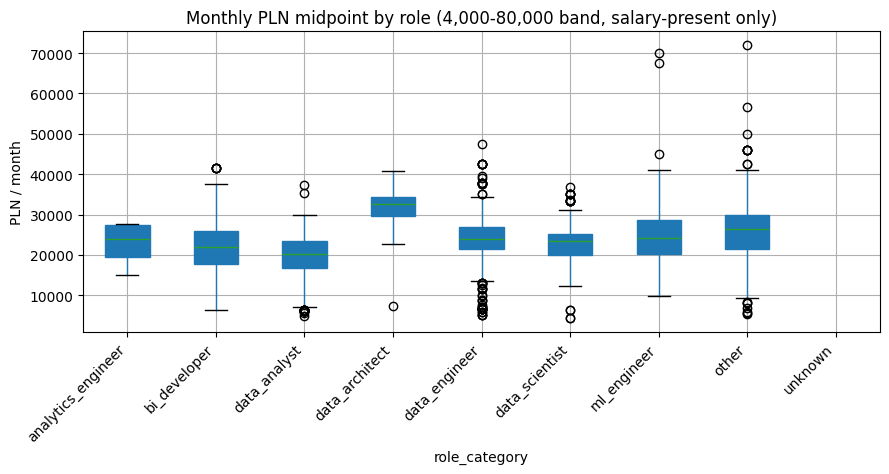

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_df = paid_ok[paid_ok["role_category"].isin(DATA_FAMILIES)]
plot_df.boxplot(
    column="salary_midpoint_pln_month",
    by="role_category",
    ax=ax,
    patch_artist=True,
)
ax.set_title(f"Monthly PLN midpoint by role ({SAL_LO:,}-{SAL_HI:,} band, salary-present only)")
ax.set_xlabel("role_category")
ax.set_ylabel("PLN / month")
plt.suptitle("")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Skills (extracted rows only)

In [14]:
skills_df = data_df[data_df["skills_norm"].notna()].copy()
print(f"Rows with skills: {len(skills_df):,}")

# Explode the alias-normalized list[str] → one row per skill token.
skill_rows = (
    skills_df[["posting_id", "role_category", "skills_norm"]]
    .explode("skills_norm")
    .rename(columns={"skills_norm": "skills"})
)
skill_rows = skill_rows[skill_rows["skills"].notna() & (skill_rows["skills"] != "")]
print(f"Skill mentions: {len(skill_rows):,} | distinct skills: {skill_rows['skills'].nunique():,}")

Rows with skills: 4,919
Skill mentions: 11,180 | distinct skills: 757


In [15]:
top_skills = (
    skill_rows["skills"]
    .value_counts()
    .head(25)
    .rename_axis("skill")
    .to_frame("postings")
)
top_skills

,postings
skill,
python,905
sql,838
databricks,499
azure,457
aws,453
gcp,427
power bi,321
spark,288
snowflake,237


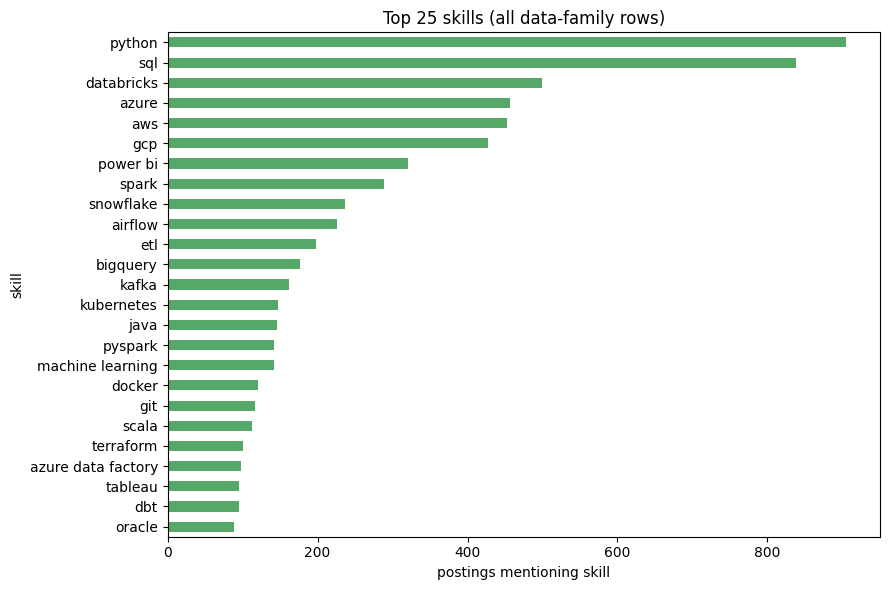

In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
top_skills["postings"].sort_values().plot.barh(ax=ax, color="#55A868")
ax.set_xlabel("postings mentioning skill")
ax.set_title("Top 25 skills (all data-family rows)")
plt.tight_layout()
plt.show()

In [17]:
# Skill prevalence within each role family (% of family postings mentioning skill)
family_sizes = skills_df.groupby("role_category", observed=True)["posting_id"].nunique()

def top_skills_for_family(family, k=10):
    subset = skill_rows[skill_rows["role_category"] == family]
    counts = subset.groupby("skills")["posting_id"].nunique()
    pct = (100 * counts / family_sizes[family]).round(1)
    return pd.DataFrame({"postings": counts, "pct_of_family": pct}).sort_values(
        "postings", ascending=False
    ).head(k)

for fam in ["data_engineer", "data_analyst", "ml_engineer", "data_scientist"]:
    print(f"\n=== {fam} (n={family_sizes[fam]:,}) ===")
    display(top_skills_for_family(fam))


=== data_engineer (n=1,647) ===


,postings,pct_of_family
skills,,
sql,438,26.6
python,419,25.4
databricks,317,19.2
spark,234,14.2
gcp,231,14.0
azure,222,13.5
aws,209,12.7
airflow,165,10.0
snowflake,156,9.5



=== data_analyst (n=1,109) ===


,postings,pct_of_family
skills,,
sql,131,11.8
python,77,6.9
power bi,72,6.5
excel,44,4.0
uml,36,3.2
jira,34,3.1
bpmn,31,2.8
tableau,27,2.4
confluence,22,2.0



=== ml_engineer (n=556) ===


,postings,pct_of_family
skills,,
python,194,34.9
kubernetes,83,14.9
aws,72,12.9
machine learning,69,12.4
azure,68,12.2
gcp,62,11.2
docker,56,10.1
llm,50,9.0
genai,42,7.6



=== data_scientist (n=349) ===


,postings,pct_of_family
skills,,
python,80,22.9
sql,46,13.2
machine learning,39,11.2
gcp,21,6.0
azure,19,5.4
scikit-learn,18,5.2
genai,17,4.9
databricks,16,4.6
aws,15,4.3


## 6. Skill clusters (exploratory — human names them)

Unsupervised KMeans over multi-hot vectors of the top skills, on data-family
rows with ≥1 extracted skill. This surfaces co-occurring skill groups; **the
human interprets and names each cluster** (per CLAUDE.md scope note). Not a
frozen taxonomy — change `K`/`TOP_N` and re-run. The `defining_skills` column
shows each cluster's most prevalent skills (% of cluster postings).

In [18]:
import numpy as np
from sklearn.cluster import KMeans

# Multi-hot vectors over the most common normalized skills, on data-family rows
# that list >=1 skill. Exploratory only — re-runnable with a different K.
clust_df = data_df[data_df["skills_norm"].apply(lambda l: isinstance(l, list) and len(l) > 0)].copy()
TOP_N = 40
vocab = skill_rows["skills"].value_counts().head(TOP_N).index.tolist()
row_sets = [set(r) for r in clust_df["skills_norm"]]
X = np.array([[1 if s in rs else 0 for s in vocab] for rs in row_sets])
print(f"Clustering {len(clust_df):,} data-family rows (>=1 skill) over top {TOP_N} skills.")

K = 8
km = KMeans(n_clusters=K, random_state=42, n_init=10)
clust_df["cluster"] = km.fit_predict(X)

# KMeans centroid on binary features == per-skill prevalence within the cluster.
rows = []
for c in range(K):
    sub = clust_df[clust_df["cluster"] == c]
    prev = pd.Series(km.cluster_centers_[c], index=vocab).sort_values(ascending=False)
    top = ", ".join(f"{s} {p*100:.0f}%" for s, p in prev.head(6).items() if p > 0)
    dom = sub["role_category"].value_counts(normalize=True)
    rows.append({
        "n": len(sub),
        "dominant_role": f"{dom.index[0]} ({dom.iloc[0]*100:.0f}%)",
        "defining_skills": top,
        "name": "<-- you name this",
    })
pd.set_option("display.max_colwidth", None)
clusters = pd.DataFrame(rows).rename_axis("cluster").sort_values("n", ascending=False)
clusters

Clustering 2,713 data-family rows (>=1 skill) over top 40 skills.


,n,dominant_role,defining_skills,name
cluster,,,,
2,1308,data_engineer (38%),"sql 15%, power bi 10%, aws 9%, gcp 7%, azure 7%, snowflake 7%",<-- you name this
6,475,data_engineer (33%),"python 100%, sql 41%, aws 13%, kubernetes 11%, pyspark 10%, etl 10%",<-- you name this
7,313,data_engineer (53%),"databricks 100%, azure 33%, python 15%, aws 13%, sql 10%, snowflake 10%",<-- you name this
0,160,data_engineer (70%),"bigquery 95%, gcp 94%, sql 54%, python 39%, airflow 35%, terraform 18%",<-- you name this
5,131,data_engineer (79%),"python 98%, databricks 94%, sql 94%, spark 53%, azure 53%, azure data factory 37%",<-- you name this
1,124,ml_engineer (48%),"aws 92%, gcp 79%, azure 78%, python 70%, docker 23%, sql 22%",<-- you name this
3,110,analytics_engineer (31%),"power bi 99%, sql 99%, tableau 56%, aws 48%, azure 42%, gcp 40%",<-- you name this
4,92,data_engineer (86%),"spark 89%, sql 85%, kafka 83%, python 79%, airflow 72%, aws 64%",<-- you name this


## 7. Location & remote

In [19]:
data_df["remote_mode"].value_counts().to_frame("count")

,count
remote_mode,
unknown,4919


In [20]:
(
    data_df["city"]
    .value_counts(dropna=False)
    .head(15)
    .rename_axis("city")
    .to_frame("count")
)

,count
city,
Warszawa,1638
NaN,727
Kraków,589
Wrocław,427
Gdańsk,419
Poznań,255
Katowice,146
Łódź,141
Lublin,63


## 8. Scratch — filter & inspect

Use this cell to drill into a subset. Examples:
- `df.query("role_category == 'data_engineer' and seniority == 'senior'")`
- `df[df['title'].str.contains('spark', case=False, na=False)]`

In [21]:
# your filters here
sample = data_df.sample(5, random_state=42)
sample[[
    "title", "role_category", "seniority", "city",
    "salary_midpoint_pln_month", "skills", "url",
]]

,title,role_category,seniority,city,salary_midpoint_pln_month,skills,url
752,Analityk Biznesowo-Systemowy,data_analyst,mid,Warszawa,<NA>,[],https://www.adzuna.pl/land/ad/5686647296?se=HDHReYBi8RGI27gKLue9KA&utm_medium=api&utm_source=7950e0aa&v=43127E1B1313A7350AEE8E8D186BF20B1D745D02
10736,AI Infrastructure Engineer / MLOps (k/m),ml_engineer,unknown,NaN,<NA>,[],https://www.adzuna.pl/details/5742747696?utm_medium=api&utm_source=7950e0aa
8661,AI/ML Engineer (Remote),ml_engineer,mid,Warszawa,24800.0,"[azure ai foundry, azure machine learning, mlflow, docker, kubernetes, ci/cd]",https://www.adzuna.pl/details/5743717512?utm_medium=api&utm_source=7950e0aa
7561,Senior Data Engineer - Tech Lead - GCP / BigQuery / dbt,data_engineer,lead,Warszawa,<NA>,"[gcp, bigquery, dbt, looker, hadoop]",https://www.adzuna.pl/land/ad/5755237782?se=Im2RYH5i8RGI27gKLue9KA&utm_medium=api&utm_source=7950e0aa&v=428726E0F2058792D9F904F0FDFEB74F6E4D5641
7245,Data Platform Architect Snowflake,other,lead,Gdańsk,39000.0,[snowflake],https://www.adzuna.pl/land/ad/5749947797?se=nlQoon5i8RGHk5mrcEw0_Q&utm_medium=api&utm_source=7950e0aa&v=7876FE1C94A2AFCCB9F56D7F79799224CF14AD3B
